# Tiền xử lý FaceForensics++ C23 — Cache RIÊNG cho nhánh rPPG

**Notebook này ĐỘC LẬP với `prepareData_16072026_v1.ipynb`** — không đụng, không ghi đè lên
cache spatial (`ffpp_c23_cache/`) đã đóng gói thành Kaggle Dataset trước đó. Output của notebook
này sẽ được đóng gói thành **1 Kaggle Dataset mới, riêng biệt**: `ffpp-c23-rppg-cache`.

**Vì sao cần cache riêng, không dùng chung 32-frame cache cũ?**
Cache spatial lấy 32 khung hình **cách đều trên toàn bộ video** (tốt cho backbone ảnh tĩnh:
Xception/SBI/UCF), nhưng phá hoàn toàn tín hiệu rPPG — vì rPPG cần một **đoạn khung hình
liên tục, đúng frame rate gốc** để tính biến thiên màu da theo chu kỳ tim (0.7–4 Hz). Notebook
này trích riêng một đoạn liên tục (mặc định 240 khung hình ~ 8 giây ở 30fps) cho mỗi video.

**Trước khi chạy — thiết lập Kaggle Notebook:**
1. Settings → Accelerator → **GPU T4 x2**
2. Settings → Internet → **ON**
3. Add Input → dataset FaceForensics++ C23 gốc (đúng dataset đã dùng ở notebook cache spatial)
4. Add Input → dataset chứa `train.json/val.json/test.json` (dùng lại đúng dataset split đã
   dùng ở notebook cache spatial — **bắt buộc phải là cùng 1 bộ split** để 2 cache khớp video
   với nhau theo cùng `video_id`)

**Kết quả cuối cùng cần lưu vĩnh viễn:** thư mục `/kaggle/working/ffpp_c23_rppg_cache/`
(xem hướng dẫn đóng gói ở cell cuối notebook).

## 1. Cài đặt thư viện

In [1]:
!pip install -q facenet-pytorch --no-deps
print("Đã cài xong facenet-pytorch (MTCNN) mà không làm hỏng Numpy của Kaggle.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.6 MB/s eta 0:00:00
Đã cài xong facenet-pytorch (MTCNN) mà không làm hỏng Numpy của Kaggle.


## 2. Cấu hình (CONFIG) — RIÊNG cho cache rPPG, không dùng chung với cache spatial

In [2]:
import os, json, cv2, glob, time, gc, shutil
import numpy as np
import pandas as pd
from pathlib import Path
import torch
import warnings
warnings.filterwarnings("ignore")

# ==================== DUONG DAN DATASET GOC (giong het notebook cache spatial) ====================
FF_ROOT = "/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23"
REAL_DIR = os.path.join(FF_ROOT, "original")
FAKE_METHODS = ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]
FAKE_DIRS = {m: os.path.join(FF_ROOT, m) for m in FAKE_METHODS}

# ==================== FILE SPLIT CHINH THUC - PHAI DUNG DUNG BO DA DUNG CHO CACHE SPATIAL ====================
POSSIBLE_SPLIT_DIRS = [
    "/kaggle/input/datasets/peiyuanzhang/ff-split",
    "/kaggle/working",
    "/kaggle/input/ffpp-splits",
    "/kaggle/input/ff-splits",
    "/kaggle/input/ffpp-c23-splits",
]
SPLIT_JSON_DIR = None
for d in POSSIBLE_SPLIT_DIRS:
    if os.path.exists(os.path.join(d, "train.json")):
        SPLIT_JSON_DIR = d
        break
if SPLIT_JSON_DIR is None:
    raise FileNotFoundError(
        "Khong tim thay train.json/val.json/test.json. Hay dung DUNG bo split da dung cho "
        "cache spatial (ffpp_c23_cache) de 2 cache khop video_id voi nhau."
    )
print("Dung file split tu:", SPLIT_JSON_DIR)

# ==================== NOI LUU CACHE rPPG - TEN FOLDER KHAC, KHONG TRUNG CACHE SPATIAL ====================
OUT_DIR = "/kaggle/working/ffpp_c23_rppg_cache"
os.makedirs(OUT_DIR, exist_ok=True)

# ==================== THAM SO TRICH XUAT RIENG CHO rPPG ====================
CONSEC_FRAMES   = 240   # so khung hinh LIEN TUC trich ra moi video (~8s @30fps, ~10s @24fps)
SKIP_EDGE_RATIO = 0.10  # bo qua 10% dau va 10% cuoi video (thuong kem on dinh: intro/outro)
FACE_MARGIN     = 1.3   # giu giong cache spatial de 2 nhanh co vung mat tuong thich
IMG_SIZE        = 192   # rPPG khong can anh lon nhu spatial (256) -> giam dung luong dang ke
JPEG_QUALITY    = 92
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)
print("FF_ROOT ton tai:", os.path.isdir(FF_ROOT))
print("OUT_DIR (RIENG cho rPPG, khong dung cache spatial cu):", OUT_DIR)


Dung file split tu: /kaggle/input/datasets/peiyuanzhang/ff-split
Device: cuda
FF_ROOT ton tai: True
OUT_DIR (RIENG cho rPPG, khong dung cache spatial cu): /kaggle/working/ffpp_c23_rppg_cache


## 3. Đọc file split & dựng danh sách video cần xử lý

**Giống hệt logic ở notebook cache spatial** (đảm bảo 2 cache có cùng danh sách video,
cùng `video_id`, cùng cách gán split) — chỉ khác bước trích xuất ở Mục 5.

In [3]:
def load_split(name):
    with open(os.path.join(SPLIT_JSON_DIR, f"{name}.json")) as f:
        return json.load(f)

splits = {s: load_split(s) for s in ["train", "val", "test"]}
for s, pairs in splits.items():
    ids = set()
    for a, b in pairs:
        ids.add(a); ids.add(b)
    print(f"{s:5s}: {len(pairs):4d} cap  ->  {len(ids):4d} video real  ->  {len(ids)*4:4d} video fake/phuong phap")


def build_manifest(pairs, split_name):
    rows = []
    real_ids = set()
    for a, b in pairs:
        real_ids.add(a)
        real_ids.add(b)

    for rid in sorted(real_ids):
        rows.append({
            "split": split_name, "label": 0, "method": "original",
            "video_id": rid,
            "src_path": os.path.join(REAL_DIR, f"{rid}.mp4"),
        })

    for a, b in pairs:
        for x, y in [(a, b), (b, a)]:
            fname = f"{x}_{y}.mp4"
            vid_id = f"{x}_{y}"
            for method in FAKE_METHODS:
                rows.append({
                    "split": split_name, "label": 1, "method": method,
                    "video_id": vid_id,
                    "src_path": os.path.join(FAKE_DIRS[method], fname),
                })
    return pd.DataFrame(rows)


manifest = pd.concat(
    [build_manifest(splits[s], s) for s in ["train", "val", "test"]],
    ignore_index=True,
)
print("\nTong video can xu ly (ly thuyet):", len(manifest))
print(manifest.groupby(["split", "method"])["video_id"].count())


train:  360 cap  ->   720 video real  ->  2880 video fake/phuong phap
val  :   70 cap  ->   140 video real  ->   560 video fake/phuong phap
test :   70 cap  ->   140 video real  ->   560 video fake/phuong phap

Tong video can xu ly (ly thuyet): 5000
split  method        
test   Deepfakes         140
       Face2Face         140
       FaceSwap          140
       NeuralTextures    140
       original          140
train  Deepfakes         720
       Face2Face         720
       FaceSwap          720
       NeuralTextures    720
       original          720
val    Deepfakes         140
       Face2Face         140
       FaceSwap          140
       NeuralTextures    140
       original          140
Name: video_id, dtype: int64


## 4. Kiểm tra video thực sự tồn tại trên đĩa

In [4]:
manifest["exists"] = manifest["src_path"].apply(os.path.exists)
n_missing = (~manifest["exists"]).sum()
print(f"So video KHONG ton tai tren dia: {n_missing} / {len(manifest)}")

manifest_full = manifest.copy()
manifest = manifest[manifest["exists"]].reset_index(drop=True)
manifest_full.to_csv(os.path.join(OUT_DIR, "manifest_theoretical.csv"), index=False)
manifest.to_csv(os.path.join(OUT_DIR, "manifest_actual.csv"), index=False)

print("\n=== So video THUC TE se xu ly ===")
summary = manifest.groupby(["split", "label"])["video_id"].count().unstack(fill_value=0)
summary.columns = ["real", "fake"]
print(summary)


So video KHONG ton tai tren dia: 0 / 5000

=== So video THUC TE se xu ly ===
       real  fake
split            
test    140   560
train   720  2880
val     140   560


## 5. Face detector (MTCNN) & hàm trích ĐOẠN LIÊN TỤC cho rPPG

**Khác biệt cốt lõi so với cache spatial:**
1. **Chọn 1 đoạn liên tục** `CONSEC_FRAMES` khung hình (không rải đều cả video) — ưu tiên đoạn
   giữa video (bỏ `SKIP_EDGE_RATIO` đầu/cuối), giữ đúng thứ tự thời gian gốc.
2. **Dò khuôn mặt 1 lần trên khung hình tham chiếu** (khung giữa đoạn clip), rồi **dùng lại đúng
   1 bounding box cố định** cho toàn bộ đoạn clip — thay vì dò lại từng frame như cache spatial.
   Lý do: nếu box "nhảy" (jitter) qua từng frame do sai số detector, sẽ sinh ra nhiễu chuyển động
   giả trong tín hiệu màu da, làm hỏng rPPG. Cố định 1 box giúp tín hiệu ổn định hơn nhiều.
3. **Lưu kèm fps thật của video** vào `clip_meta.csv` — bắt buộc phải biết fps để lọc bandpass
   đúng dải tần số tim (0.7–4 Hz) khi xử lý tín hiệu ở bước sau.

In [5]:
from facenet_pytorch import MTCNN

mtcnn = MTCNN(image_size=IMG_SIZE, margin=0, keep_all=False,
              post_process=False, select_largest=True, device=DEVICE)


def detect_face_box(frame_rgb):
    """Do khuon mat tren 1 khung hinh, tra ve box da ap margin (x1,y1,x2,y2) hoac None."""
    h, w = frame_rgb.shape[:2]
    try:
        boxes, probs = mtcnn.detect(frame_rgb)
    except Exception:
        boxes, probs = None, None

    if boxes is None or len(boxes) == 0:
        return None

    idx = int(np.argmax(probs))
    x1, y1, x2, y2 = boxes[idx]
    bw, bh = x2 - x1, y2 - y1
    cx, cy = x1 + bw / 2, y1 + bh / 2
    half = max(bw, bh) * FACE_MARGIN / 2
    x1, y1 = int(max(cx - half, 0)), int(max(cy - half, 0))
    x2, y2 = int(min(cx + half, w)), int(min(cy + half, h))
    return (x1, y1, x2, y2)


def crop_with_box(frame_rgb, box):
    x1, y1, x2, y2 = box
    crop = frame_rgb[y1:y2, x1:x2]
    if crop.size == 0:
        h, w = frame_rgb.shape[:2]
        s = min(h, w)
        cy, cx = h // 2, w // 2
        crop = frame_rgb[cy - s // 2: cy + s // 2, cx - s // 2: cx + s // 2]
    return cv2.resize(crop, (IMG_SIZE, IMG_SIZE))


def extract_rppg_clip(video_path, out_dir, consec_frames=CONSEC_FRAMES, skip_ratio=SKIP_EDGE_RATIO):
    """Trich 1 doan lien tuc `consec_frames` khung hinh quanh giua video, dung 1 box co dinh."""
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    if total <= 0:
        cap.release()
        return 0, fps, 0

    usable_start = int(total * skip_ratio)
    usable_end = int(total * (1 - skip_ratio))
    usable_len = max(usable_end - usable_start, 1)
    n_frames = min(consec_frames, usable_len, total)

    # Diem bat dau doan clip: canh giua vung usable
    start_frame = usable_start + max((usable_len - n_frames) // 2, 0)

    # ----- Buoc 1: doc khung hinh tham chieu (giua doan clip) de do box co dinh -----
    ref_frame_idx = start_frame + n_frames // 2
    cap.set(cv2.CAP_PROP_POS_FRAMES, ref_frame_idx)
    ret, ref_frame = cap.read()
    if not ret:
        cap.release()
        return 0, fps, 0
    ref_rgb = cv2.cvtColor(ref_frame, cv2.COLOR_BGR2RGB)
    box = detect_face_box(ref_rgb)
    if box is None:
        h, w = ref_rgb.shape[:2]
        s = min(h, w)
        box = (w // 2 - s // 2, h // 2 - s // 2, w // 2 + s // 2, h // 2 + s // 2)

    # ----- Buoc 2: doc lai tu dau doan clip, crop toan bo bang dung 1 box da do -----
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    saved = 0
    for i in range(n_frames):
        ret, frame = cap.read()
        if not ret:
            break
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        crop = crop_with_box(frame_rgb, box)
        out_path = os.path.join(out_dir, f"frame_{saved:03d}.jpg")
        cv2.imwrite(out_path, cv2.cvtColor(crop, cv2.COLOR_RGB2BGR),
                    [int(cv2.IMWRITE_JPEG_QUALITY), JPEG_QUALITY])
        saved += 1
    cap.release()
    return saved, fps, start_frame


def print_disk_usage(path="/kaggle/working"):
    total, used, free = shutil.disk_usage(path)
    print(f"    [Disk {path}] Used: {used/1e9:.2f} GB | Free: {free/1e9:.2f} GB")


## 6. Vòng lặp xử lý chính — tuần tự theo nhóm, có checkpoint/resume

Giống nguyên tắc chống tràn bộ nhớ / mất tiến độ ở notebook cache spatial: xử lý tuần tự
từng nhóm `(split, method)`, tự resume nếu bị ngắt, lưu checkpoint CSV sau mỗi nhóm.

**Lưu ý dung lượng:** vì mỗi video lưu 240 ảnh (thay vì 32) nhưng ở `IMG_SIZE=192` (thay vì 256),
tổng dung lượng ước tính khoảng **7-8× cache spatial** (~25-30GB cho toàn bộ 5000 video). Nếu
vượt quota lưu trữ Kaggle, giảm `CONSEC_FRAMES` (ví dụ 150) ở Mục 2 rồi chạy lại.

In [6]:
from tqdm import tqdm

CHECKPOINT_CSV = os.path.join(OUT_DIR, "manifest_processed.csv")
META_CSV = os.path.join(OUT_DIR, "clip_meta.csv")


def process_group(df_group, group_name):
    results = []
    print(f"\n=== Xu ly nhom: {group_name}  ({len(df_group)} video) ===")
    for i, row in enumerate(tqdm(df_group.itertuples(), total=len(df_group))):
        sub = "real" if row.label == 0 else f"fake_{row.method}"
        out_dir = os.path.join(OUT_DIR, row.split, sub, row.video_id)

        existing = len(glob.glob(os.path.join(out_dir, "*.jpg"))) if os.path.isdir(out_dir) else 0
        if existing >= int(CONSEC_FRAMES * 0.8):
            results.append(dict(video_id=row.video_id, split=row.split, label=row.label,
                                 method=row.method, out_dir=out_dir, n_frames=existing,
                                 fps=None, start_frame=None, status="skip_exists"))
            continue

        os.makedirs(out_dir, exist_ok=True)
        try:
            n, fps, start_frame = extract_rppg_clip(row.src_path, out_dir)
            status = "ok" if n >= CONSEC_FRAMES * 0.8 else "partial"
        except Exception as e:
            n, fps, start_frame, status = 0, None, None, f"error: {e}"

        results.append(dict(video_id=row.video_id, split=row.split, label=row.label,
                             method=row.method, out_dir=out_dir, n_frames=n,
                             fps=fps, start_frame=start_frame, status=status))

        if i % 200 == 0 and i > 0:
            print_disk_usage()
            gc.collect()

    return pd.DataFrame(results)


groups = [(s, "original") for s in ["train", "val", "test"]]
for s in ["train", "val", "test"]:
    for m in FAKE_METHODS:
        groups.append((s, m))

if os.path.exists(CHECKPOINT_CSV):
    print("Tim thay checkpoint cu, se tiep tuc dua tren cac thu muc da co san.")

all_results = []
for split, method in groups:
    df_g = manifest[(manifest.split == split) & (manifest.method == method)]
    if len(df_g) == 0:
        continue
    res = process_group(df_g, f"{split}/{method}")
    all_results.append(res)
    combined = pd.concat(all_results, ignore_index=True)
    combined.to_csv(CHECKPOINT_CSV, index=False)
    combined[["video_id", "split", "fps", "start_frame", "n_frames"]].to_csv(META_CSV, index=False)
    print_disk_usage()

final_manifest = pd.concat(all_results, ignore_index=True)
final_manifest.to_csv(CHECKPOINT_CSV, index=False)
final_manifest[["video_id", "split", "fps", "start_frame", "n_frames"]].to_csv(META_CSV, index=False)

print("\n================ HOAN TAT TIEN XU LY rPPG ================")
print(final_manifest["status"].value_counts())



=== Xu ly nhom: train/original  (720 video) ===


 28%|██▊       | 201/720 [05:44<16:29,  1.91s/it]

    [Disk /kaggle/working] Used: 0.55 GB | Free: 20.39 GB


 56%|█████▌    | 401/720 [11:45<10:58,  2.07s/it]

    [Disk /kaggle/working] Used: 1.09 GB | Free: 19.86 GB


...

    [Disk /kaggle/working] Used: 12.60 GB | Free: 8.34 GB

=== Xu ly nhom: test/FaceSwap  (140 video) ===


100%|██████████| 140/140 [04:16<00:00,  1.83s/it]


    [Disk /kaggle/working] Used: 12.97 GB | Free: 7.97 GB

=== Xu ly nhom: test/NeuralTextures  (140 video) ===


100%|██████████| 140/140 [04:14<00:00,  1.82s/it]

    [Disk /kaggle/working] Used: 13.33 GB | Free: 7.61 GB

================ HOAN TAT TIEN XU LY rPPG ================
status
ok    5000
Name: count, dtype: int64


## 7. Kiểm tra kết quả — số liệu thật, ảnh mẫu, tổng dung lượng

=== So video xu ly THANH CONG theo split/label (0=real, 1=fake) ===
label    0     1
split           
test   140   560
train  720  2880
val    140   560

=== Chi tiet theo phuong phap fake ===
method  Deepfakes  Face2Face  FaceSwap  NeuralTextures
split                                                 
test          140        140       140             140
train         720        720       720             720
val           140        140       140             140


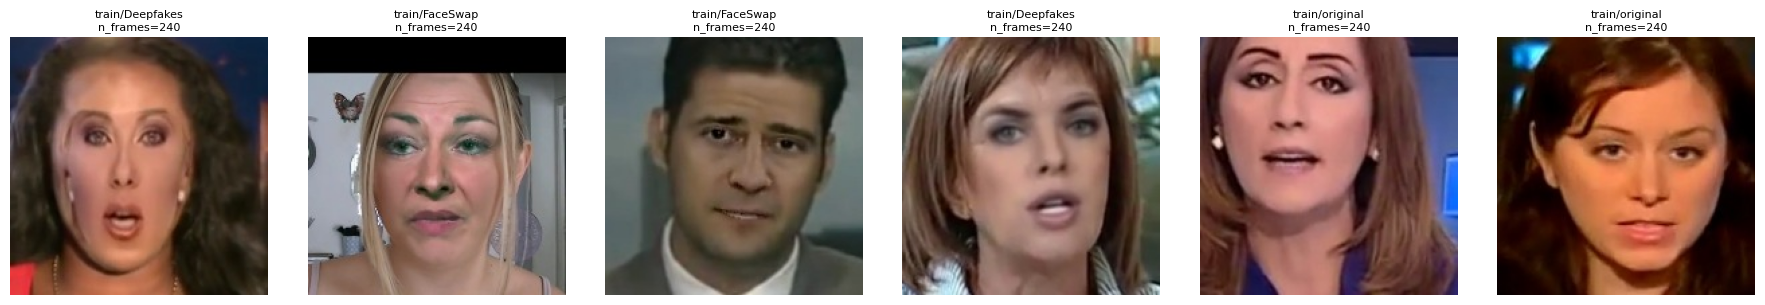


Tong dung luong cache rPPG da luu: 10.64 GB
Vi tri: /kaggle/working/ffpp_c23_rppg_cache


In [7]:
print("=== So video xu ly THANH CONG theo split/label (0=real, 1=fake) ===")
ok_mask = final_manifest["status"].isin(["ok", "skip_exists"])
print(final_manifest[ok_mask].groupby(["split", "label"])["video_id"].count().unstack(fill_value=0))

print("\n=== Chi tiet theo phuong phap fake ===")
print(final_manifest[ok_mask & (final_manifest.label == 1)]
      .groupby(["split", "method"])["video_id"].count().unstack(fill_value=0))

import matplotlib.pyplot as plt

n_ok = int(ok_mask.sum())
if n_ok == 0:
    print("\n[!] Khong co video nao xu ly thanh cong -> bo qua buoc hien thi anh mau.")
else:
    sample_rows = final_manifest[ok_mask].sample(min(6, n_ok), random_state=42)
    fig, axes = plt.subplots(1, len(sample_rows), figsize=(3 * len(sample_rows), 3))
    if len(sample_rows) == 1:
        axes = [axes]
    for ax, row in zip(axes, sample_rows.itertuples()):
        imgs = sorted(glob.glob(os.path.join(row.out_dir, "*.jpg")))
        if imgs:
            img = cv2.cvtColor(cv2.imread(imgs[0]), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
        ax.set_title(f"{row.split}/{row.method}\nn_frames={row.n_frames}", fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "sample_preview.png"), dpi=100)
    plt.show()

def get_dir_size(path):
    total = 0
    for dirpath, _, filenames in os.walk(path):
        for fn in filenames:
            total += os.path.getsize(os.path.join(dirpath, fn))
    return total

size_gb = get_dir_size(OUT_DIR) / 1e9
print(f"\nTong dung luong cache rPPG da luu: {size_gb:.2f} GB")
print(f"Vi tri: {OUT_DIR}")


## 8. ⚠️ QUAN TRỌNG — Lưu cache rPPG VĨNH VIỄN, đóng gói THÀNH DATASET RIÊNG

Giống nguyên tắc ở notebook cache spatial, nhưng nhớ **đặt tên Dataset khác** để không lẫn lộn.

### Bước 1 — Lưu version của notebook
Góc trên bên phải → **Save Version** → **Save & Run All (Commit)**.

### Bước 2 — Tạo Kaggle Dataset MỚI, TÁCH RIÊNG khỏi cache spatial
1. Vào tab **Output** của version vừa chạy
2. Sẽ thấy thư mục `ffpp_c23_rppg_cache/` trong output (khác hoàn toàn `ffpp_c23_cache/` cũ)
3. Bấm **New Dataset** từ chính output này
4. Đặt tên: `ffpp-c23-rppg-cache` (**khác tên** `ffpp-c23-face-cache` đã tạo trước đó)
   → **Create**

→ Kết quả: bạn có **2 Kaggle Dataset độc lập, tồn tại vĩnh viễn**:
- `ffpp-c23-face-cache` — 32 frame/video, dùng cho Xception/SBI/UCF + nhánh spatial
- `ffpp-c23-rppg-cache` — ~240 frame liên tục/video, dùng cho nhánh rPPG

### Bước 3 — Dùng cả 2 dataset cùng lúc khi train mô hình đề xuất
Trong notebook train `DeepfakeFusionModel`:
1. Add Input → cả `ffpp-c23-face-cache` **và** `ffpp-c23-rppg-cache`
2. Join 2 manifest theo `video_id` để lấy đúng cặp (ảnh spatial, đoạn clip rPPG) của cùng 1 video
3. Đọc `clip_meta.csv` để lấy `fps` thật của từng video khi tính bandpass filter tín hiệu rPPG

### Cấu trúc thư mục cache rPPG cuối cùng
```
ffpp_c23_rppg_cache/
├── manifest_processed.csv      # video_id, split, label, method, out_dir, n_frames, fps, status
├── manifest_theoretical.csv
├── clip_meta.csv                # video_id, split, fps, start_frame, n_frames (dùng cho xử lý tín hiệu)
├── sample_preview.png
├── train/
│   ├── real/{video_id}/frame_000.jpg ... frame_239.jpg
│   ├── fake_Deepfakes/{video_id}/...
│   ├── fake_Face2Face/{video_id}/...
│   ├── fake_FaceSwap/{video_id}/...
│   └── fake_NeuralTextures/{video_id}/...
├── val/        (cấu trúc tương tự train/)
└── test/       (cấu trúc tương tự train/)
```

**Lưu ý:** cấu trúc `split/label_hoặc_method/video_id/` giống hệt cache spatial — chỉ số lượng
ảnh, tên file, và có thêm `clip_meta.csv` là khác. Nhờ vậy join 2 cache theo `video_id` rất
đơn giản khi dựng `Dataset` đa nhánh cho `DeepfakeFusionModel`.